In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [56]:
df = pd.read_csv('credit_card_fraud_10k.csv')

In [57]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [58]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [59]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [61]:
df['merchant_category'].unique()

<StringArray>
['Electronics', 'Travel', 'Grocery', 'Food', 'Clothing']
Length: 5, dtype: str

In [62]:
encoder = LabelEncoder()
df['merchant_category'] = encoder.fit_transform(df['merchant_category'])

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  int64  
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [ ]:
X = df.drop('is_fraud',axis=1)
y = df['is_fraud']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [66]:
kernels = ['linear','poly','rbf']
accuracy = []

for k in kernels:
    if k == 'linear':
        model = SVC(kernel='linear', C=1, class_weight='balanced')
    elif k == 'poly':
        model = SVC(kernel='poly', degree=3, C=1, class_weight='balanced')
    else:
        model = SVC(kernel='rbf', gamma='scale', C=1, class_weight='balanced')

    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test,y_pred))

for k, acc in zip(kernels, accuracy):
    print(f"{k} kernel accuracy: {acc:.4f}")

linear kernel accuracy: 0.9505
poly kernel accuracy: 0.9915
rbf kernel accuracy: 0.9900


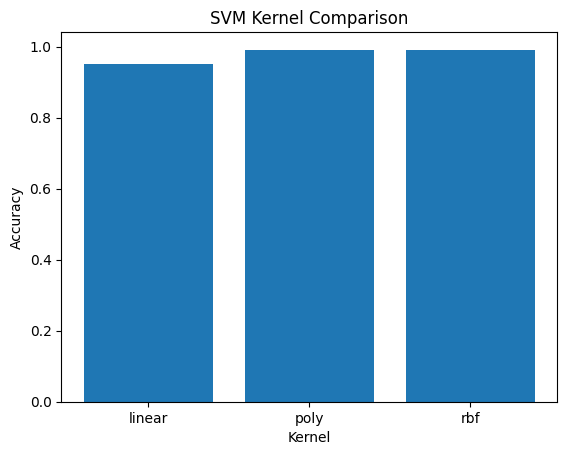

In [67]:
import matplotlib.pyplot as plt

plt.bar(kernels, accuracy)
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison")
plt.show()

In [68]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1954   15]
 [   5   26]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1969
           1       0.63      0.84      0.72        31

    accuracy                           0.99      2000
   macro avg       0.82      0.92      0.86      2000
weighted avg       0.99      0.99      0.99      2000



* Linear kernel performs well when data is linearly separable
* Polynomial kernel captures curved relationships but may overfit
* RBF kernel gives best performance due to handling complex patterns